# 🌍 TiVA Time-Machine — Starting Kit

**Objectif** : prédire les flux de valeur ajoutée TiVA des pays du G7 vers 80+ économies,
à partir d'indicateurs macro-économiques disponibles en temps réel.

**Métrique** : `Score = 0.3 × MAE_public(2016-2018) + 0.7 × MAE_private(2019-2020)`

**Baseline** : Random Forest sans tuning → score ~45 097

---

## 1. Chargement des données

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Adapter le chemin selon votre environnement
DATA_DIR = 'dev_phase/input_data/'

X_train = pd.read_csv(DATA_DIR + 'X_train.csv')
X_test = pd.read_csv(DATA_DIR + 'X_test.csv')

y_train = pd.read_csv(DATA_DIR + 'y_train.csv')
y_test = pd.read_csv(DATA_DIR + 'y_test.csv')

df_train = pd.concat([X_train, y_train['TiVA_Value_Target']], axis=1)
df_test = pd.concat([X_test, y_test['TiVA_Value_Target']], axis=1)

print(f'Train : {df_train.shape} | années {df_train.Year.min()}-{df_train.Year.max()}')
print(f'Test  : {df_test.shape}  | années {df_test.Year.min()}-{df_test.Year.max()}')
df_train.head(3)

Train : (6083, 28) | années 2005-2015
Test  : (2765, 28)  | années 2016-2020


,Source_Country,Target_Country,Sector_Code,Year,Sector_Name,country_x,GDP_USD_Source,GDP_Growth_Source,Inflation_Source,FDI_Inflow_Source,...,GDP_Growth_Target,Inflation_Target,FDI_Inflow_Target,Trade_Openness_Target,Internet_Users_Target,HighTech_Export_Target,Research_Spend_Target,Unemployment_Target,Population_Target,TiVA_Value_Target
0,CAN,AGO,GTN,2005,GTN,Canada,1.173109e+12,3.210454,2.213552,2.178164,...,14.154778,22.953514,-3.149620,95.341459,1.14337,12.604486,NaN,16.295,19291161.0,110.737
1,CAN,ARE,GTN,2005,GTN,Canada,1.173109e+12,3.210454,2.213552,2.178164,...,4.855141,12.250420,6.034816,119.552872,40.00000,3.306515,0.47252,3.120,4664790.0,285.426
2,CAN,ARG,GTN,2005,GTN,Canada,1.173109e+12,3.210454,2.213552,2.178164,...,8.851660,NaN,2.649354,40.551271,17.72060,6.961723,0.42074,11.506,39216789.0,214.941


In [53]:
y_train

,Year,Source_Country,Target_Country,TiVA_Value_Target
0,2005,CAN,AGO,110.737
1,2005,CAN,ARE,285.426
2,2005,CAN,ARG,214.941
3,2005,CAN,AUS,1027.088
4,2005,CAN,AUT,356.668
...,...,...,...,...
6078,2015,USA,TUR,8457.527
6079,2015,USA,TWN,13998.616
6080,2015,USA,UKR,1554.656
6081,2015,USA,VNM,4505.019


## 2. Feature Engineering

In [55]:
X_test.columns

Index(['Source_Country', 'Target_Country', 'Sector_Code', 'Year',
       'Sector_Name', 'country_x', 'GDP_USD_Source', 'GDP_Growth_Source',
       'Inflation_Source', 'FDI_Inflow_Source', 'Trade_Openness_Source',
       'Internet_Users_Source', 'HighTech_Export_Source',
       'Research_Spend_Source', 'Unemployment_Source', 'Population_Source',
       'country_y', 'GDP_USD_Target', 'GDP_Growth_Target', 'Inflation_Target',
       'FDI_Inflow_Target', 'Trade_Openness_Target', 'Internet_Users_Target',
       'HighTech_Export_Target', 'Research_Spend_Target',
       'Unemployment_Target', 'Population_Target'],
      dtype='object')

In [45]:
def fill_missing(df):
    macro_cols = [c for c in df.columns if c.endswith('_Source') or c.endswith('_Target')]
    for col in macro_cols:
        group_key = 'Source_Country' if col.endswith('_Source') else 'Target_Country'
        df[col] = (df.groupby(group_key)[col]
                     .transform(lambda x: x.interpolate(method='linear').ffill().bfill()))
    return df

def feature_engineering(df):
    df['GDP_ratio']           = np.log1p(df['GDP_USD_Source']) - np.log1p(df['GDP_USD_Target'])
    df['Tech_gap']            = df['HighTech_Export_Source']   - df['HighTech_Export_Target']
    df['RnD_gap']             = df['Research_Spend_Source']    - df['Research_Spend_Target']
    df['Unemployment_gap']    = df['Unemployment_Source']      - df['Unemployment_Target']
    df['Trade_openness_mean'] = (df['Trade_Openness_Source']   + df['Trade_Openness_Target']) / 2
    df['Trade_openness_diff'] = df['Trade_Openness_Source']    - df['Trade_Openness_Target']
    df['Market_size_target']  = np.log1p(df['GDP_USD_Target']  * df['Population_Target'])
    df['GDP_per_capita_target'] = np.log1p(df['GDP_USD_Target'] / (df['Population_Target'] + 1))
    df['Macro_stability']     = -np.abs(df['Inflation_Target'])
    df['Digital_gap']         = df['Internet_Users_Source']    - df['Internet_Users_Target']
    df['Tech_intensity_source'] = df['HighTech_Export_Source'] * df['Research_Spend_Source']
    df['FDI_ratio']           = (np.log1p(df['FDI_Inflow_Source'])
                                  / (np.log1p(df['FDI_Inflow_Target']) + 1e-6))
    df['Year_norm']   = (df['Year'] - 2000) / 20
    df['Crisis_2008'] = df['Year'].isin([2008, 2009]).astype(int)
    df = pd.get_dummies(df, columns=['Source_Country', 'Sector_Code'], drop_first=False)
    drop_cols = [c for c in ['Sector_Name','Target_Country','country_x','country_y','Sector_Code_GTN'] if c in df.columns]
    return df.drop(columns=drop_cols)

df_train = fill_missing(df_train)
df_test  = fill_missing(df_test)

df_all = pd.concat([df_train, df_test], ignore_index=True)
df_all = feature_engineering(df_all)
print(f'Features après engineering : {df_all.shape[1]}')

Features après engineering : 43


## 3. Split & Normalisation

In [46]:
from sklearn.preprocessing import StandardScaler

onehot_cols = [c for c in df_all.columns if c.startswith('Source_Country_')]

train_mask = df_all['Year'] <= 2015
pub_mask   = df_all['Year'].between(2016, 2018)
priv_mask  = df_all['Year'].between(2019, 2020)

drop_cols = ['TiVA_Value_Target', 'Year']

X_train = df_all[train_mask].drop(columns=drop_cols)
y_train = df_all[train_mask]['TiVA_Value_Target']
refs_train = df_all[train_mask][onehot_cols + ['Year']]

X_pub   = df_all[pub_mask].drop(columns=drop_cols)
y_pub   = df_all[pub_mask]['TiVA_Value_Target']
refs_pub = df_all[pub_mask][onehot_cols + ['Year']]

X_priv  = df_all[priv_mask].drop(columns=drop_cols)
y_priv  = df_all[priv_mask]['TiVA_Value_Target']
refs_priv = df_all[priv_mask][onehot_cols + ['Year']]

scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_pub_sc   = pd.DataFrame(scaler.transform(X_pub),   columns=X_pub.columns,   index=X_pub.index)
X_priv_sc  = pd.DataFrame(scaler.transform(X_priv),  columns=X_priv.columns,  index=X_priv.index)

print(f'Train  : {X_train_sc.shape}')
print(f'Public : {X_pub_sc.shape}')
print(f'Privé  : {X_priv_sc.shape}')

Train  : (6083, 41)
Public : (1659, 41)
Privé  : (1106, 41)


## 4. Baseline — Random Forest

In [47]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train)

y_pred_pub  = rf.predict(X_pub_sc)
y_pred_priv = rf.predict(X_priv_sc)

print(f'MAE Public  : {mean_absolute_error(y_pub, y_pred_pub):,.2f}')
print(f'MAE Privé   : {mean_absolute_error(y_priv, y_pred_priv):,.2f}')

MAE Public  : 1,348.88
MAE Privé   : 1,776.77


## 5. Calcul du score officiel

In [48]:
def scoring_func(pred_pub, true_pub, refs_pub, pred_priv, true_priv, refs_priv):
    def _aggregate(pred, true, refs):
        refs = refs.copy()
        refs['Source_Country'] = refs[onehot_cols].idxmax(axis=1).str.replace('Source_Country_', '')
        df = refs[['Year', 'Source_Country']].reset_index(drop=True)
        df['pred'] = pd.Series(pred).values
        df['true'] = pd.Series(true).values
        return df.groupby(['Year', 'Source_Country'])[['pred', 'true']].sum()

    df_pub  = _aggregate(pred_pub,  true_pub,  refs_pub)
    df_priv = _aggregate(pred_priv, true_priv, refs_priv)

    mae_pub  = mean_absolute_error(df_pub['true'],  df_pub['pred'])
    mae_priv = mean_absolute_error(df_priv['true'], df_priv['pred'])
    score    = 0.3 * mae_pub + 0.7 * mae_priv

    print(f'MAE Public  : {mae_pub:>12,.2f}')
    print(f'MAE Privé   : {mae_priv:>12,.2f}')
    print(f'Score Final : {score:>12,.2f}')
    return score, df_pub, df_priv

score, df_pub_agg, df_priv_agg = scoring_func(
    y_pred_pub, y_pub, refs_pub,
    y_pred_priv, y_priv, refs_priv
)

MAE Public  :    43,268.24
MAE Privé   :    56,235.51
Score Final :    52,345.33


## 6. Visualisation des résultats

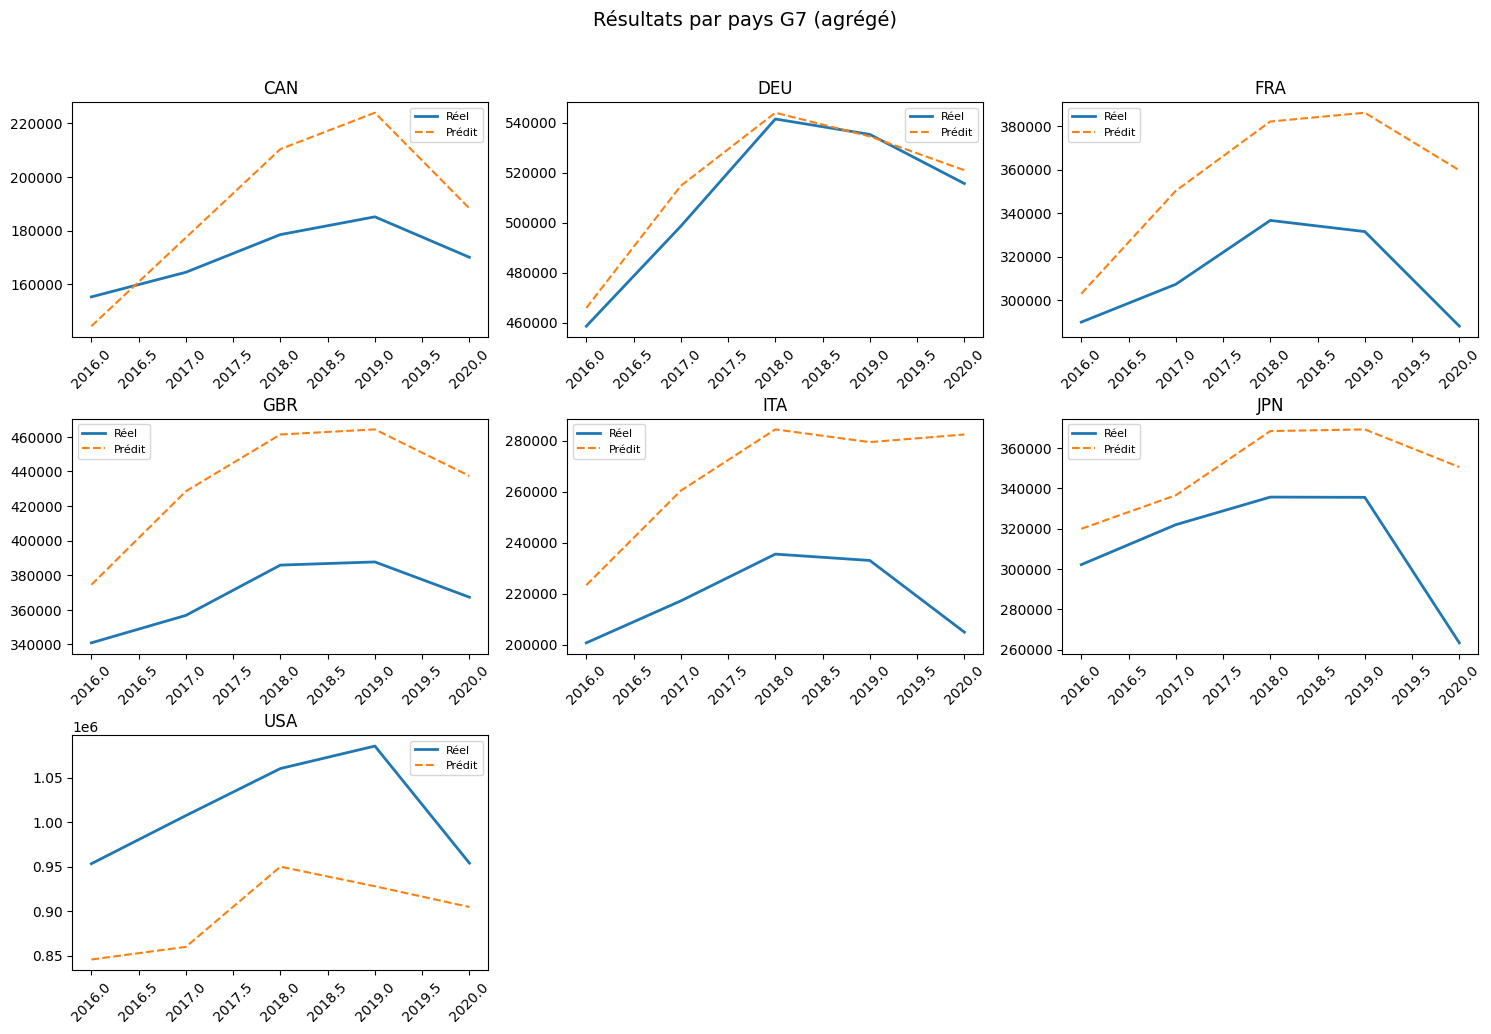

In [49]:
df_tot = pd.concat([df_pub_agg, df_priv_agg]).reset_index()
countries = df_tot['Source_Country'].unique()

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, country in enumerate(countries):
    res = df_tot[df_tot['Source_Country'] == country].set_index('Year')
    axes[i].plot(res.index, res['true'], label='Réel', linewidth=2)
    axes[i].plot(res.index, res['pred'], linestyle='--', label='Prédit')
    axes[i].set_title(country)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(fontsize=8)

for j in range(len(countries), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Résultats par pays G7 (agrégé)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Soumettre sur Codabench

Pour soumettre, créez un fichier `submission.py` avec une fonction `get_model()` :

```python
def get_model():
    from sklearn.ensemble import GradientBoostingRegressor
    return GradientBoostingRegressor(n_estimators=200, learning_rate=0.05)
```

Puis zippez-le et uploadez `submission.zip` sur Codabench.

**Pistes d'amélioration :**
- Prédire `log(1 + TiVA)` puis inverser → `exp(pred) - 1`
- XGBoost / LightGBM avec tuning des hyperparamètres
- Lag features sur TiVA (attention au data leakage !)
- Embeddings pays/secteur avec un réseau de neurones